In [215]:
import numpy as np
rng = np.random.default_rng(0)

In [216]:
class Bandit:
    def __init__(self, k):
        self.k = k
        self.q = rng.normal(0.0, 1.0, self.k)
        self.optimal_action = self.q.argmax()
        self.r_mu = self.q
        self.r_sigma = 1.0
    
    def step(self, k):
        return rng.normal(self.r_mu[k], self.r_sigma)

In [217]:
from dataclasses import dataclass

@dataclass
class Config:
    k: int
    time_steps: int
    experiments: int
    eps: float

In [218]:
def do_experiment(c: Config):
    rewards = []
    chose_optimal_action = []
    b = Bandit(c.k)
    Q = np.zeros(c.k)
    R_sum = np.zeros(c.k)
    N = np.zeros(c.k)

    def select_action():
        if c.eps > rng.random():
            return rng.integers(0, c.k)
        return Q.argmax()

    for t in range(c.time_steps):
        A = select_action()
        R = b.step(A)
        R_sum[A] += R
        N[A] += 1
        Q[A] = R_sum[A] / N[A]
        rewards.append(R)
        chose_optimal_action.append(A == b.optimal_action)

    return rewards, chose_optimal_action

In [219]:
class Metrics:
    def __init__(self, c: Config):
        self.rewards_all = np.zeros((c.experiments, c.time_steps))
        self.chose_optimal_action_all = np.zeros((c.experiments, c.time_steps))

    def reward_distribution_over_time(self):
        return np.mean(self.rewards_all, axis=0), np.std(self.rewards_all, axis=0)
    
    def optimal_action_choice_ratio_over_time(self):
        return np.mean(self.chose_optimal_action_all, axis=0)

In [220]:
import matplotlib.pyplot as plt

def plot_rewards(metrics_list: list[Metrics], config_list: list[Config]):
    for m, c in zip(metrics_list, config_list):
        mean_rewards, std_rewards = m.reward_distribution_over_time()
        x = np.arange(len(mean_rewards))
        plt.plot(x, mean_rewards, label=rf'$\epsilon = {c.eps}$')
        plt.fill_between(x, mean_rewards - std_rewards, mean_rewards + std_rewards, alpha=0.2)
    plt.xlabel("t")
    plt.ylabel("Average Reward")
    plt.legend()
    plt.show()

def plot_optimal_action_ratio(metrics_list: list[Metrics], config_list: list[Config]):
    for m, c in zip(metrics_list, config_list):
        y = m.optimal_action_choice_ratio_over_time()
        x = np.arange(len(y))
        plt.plot(x, y, label=rf'$\epsilon = {c.eps}$')
    plt.ylim(0.0, 1.0)
    plt.xlabel("t")
    plt.ylabel("Optimal action ratio")
    plt.legend()
    plt.show()

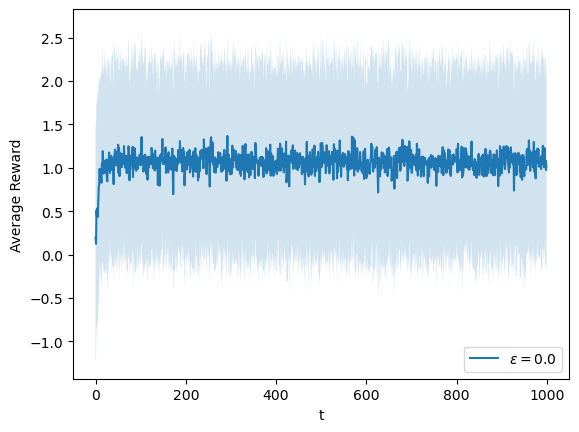

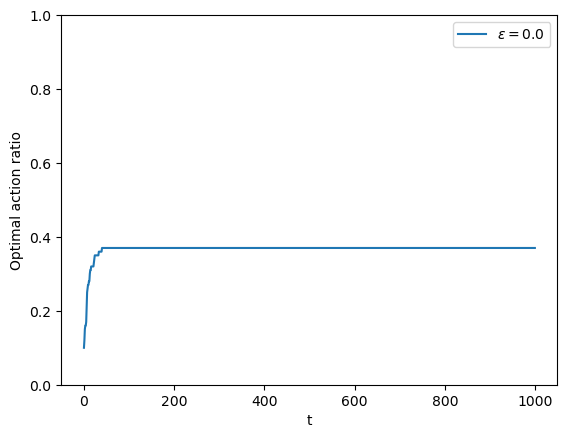

In [221]:
c = Config(
    k = 10,
    time_steps = 1000,
    experiments = 100,
    eps = 0.0
)
m = Metrics(c)

for exp_nr in range(c.experiments):
    rewards, chose_optimal_action = do_experiment(c)
    
    m.rewards_all[exp_nr] = np.array(rewards)
    m.chose_optimal_action_all[exp_nr] = np.array(chose_optimal_action)

plot_rewards([m], [c])
plot_optimal_action_ratio([m], [c])

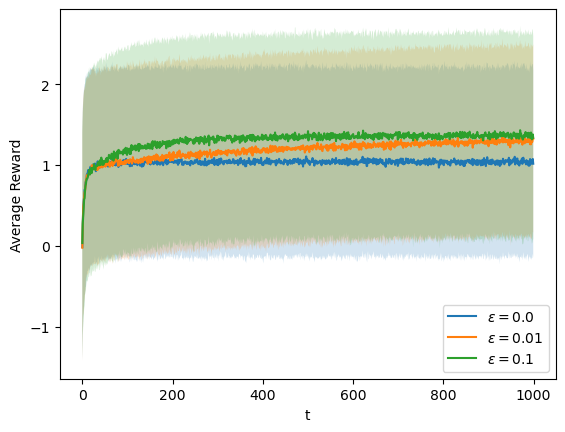

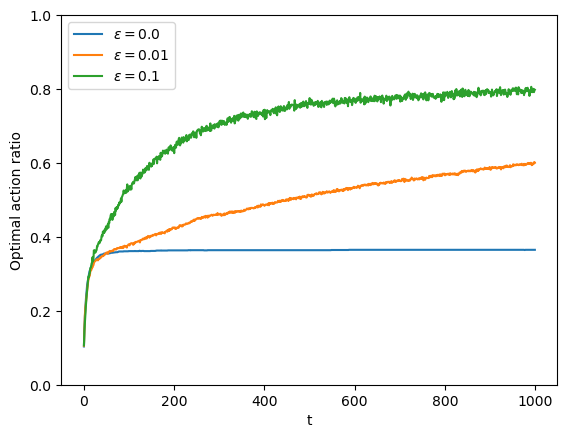

In [222]:
import copy
c1 = Config(
    k = 10,
    time_steps = 1000,
    experiments = 2000,
    eps = 0.0
)
c2 = copy.deepcopy(c1)
c2.eps = 0.01
c3 = copy.deepcopy(c1)
c3.eps = 0.1
configs = (c1, c2, c3)

metrics = []
for c in configs:
    m = Metrics(c)
    metrics.append(m)

    for exp_nr in range(c.experiments):
        rewards, chose_optimal_action = do_experiment(c)
        
        m.rewards_all[exp_nr] = np.array(rewards)
        m.chose_optimal_action_all[exp_nr] = np.array(chose_optimal_action)

plot_rewards(metrics, configs)
plot_optimal_action_ratio(metrics, configs)

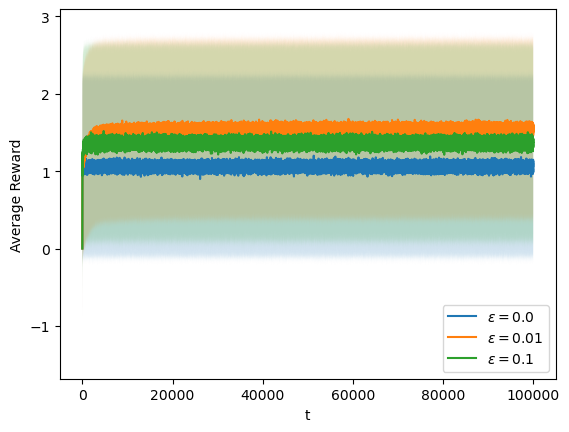

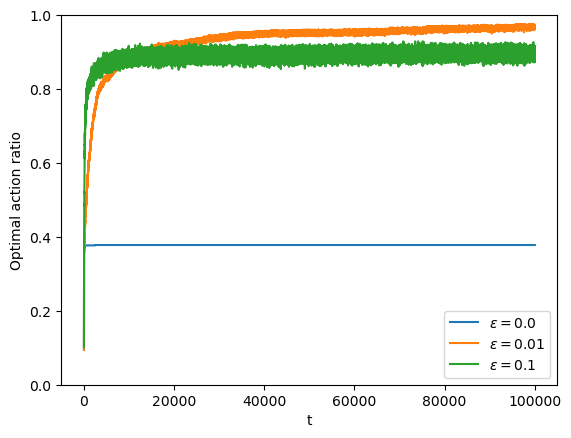

In [228]:
import copy
c1 = Config(
    k = 10,
    time_steps = 100000,
    experiments = 1000,
    eps = 0.0
)
c2 = copy.deepcopy(c1)
c2.eps = 0.01
c3 = copy.deepcopy(c1)
c3.eps = 0.1
configs = (c1, c2, c3)

metrics = []
for c in configs:
    m = Metrics(c)
    metrics.append(m)

    for exp_nr in range(c.experiments):
        rewards, chose_optimal_action = do_experiment(c)
        
        m.rewards_all[exp_nr] = np.array(rewards)
        m.chose_optimal_action_all[exp_nr] = np.array(chose_optimal_action)

plot_rewards(metrics, configs)
plot_optimal_action_ratio(metrics, configs)